In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("archive/data-final.csv", sep="\t")

df.shape


(1015341, 110)

In [3]:

df.head()


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


In [5]:
#df.columns.tolist()

In [6]:
df = df[df["IPC"] == 1]
df.shape

(696845, 110)

In [7]:
cols_noE = [
    col for col in df.columns
    if col.startswith(("EXT", "EST", "AGR", "CSN", "OPN"))
    and not col.endswith("_E")
]

df_noE = df[cols_noE]


In [8]:
df_noE.isnull().sum().sort_values(ascending=False).head()


EXT1     1141
CSN8     1141
AGR8     1141
AGR9     1141
AGR10    1141
dtype: int64

In [9]:
empty_rows = df_noE.isnull().all(axis=1)

empty_rows.sum()



1141

In [10]:
df_noE = df_noE.dropna(how="all")
empty_rows = df_noE.isnull().all(axis=1)

empty_rows.sum()


0

In [11]:
df_noE.isnull().sum().sort_values(ascending=False).head()


EXT1     0
CSN8     0
AGR8     0
AGR9     0
AGR10    0
dtype: int64

In [12]:
cols_withE = [
    col for col in df.columns
    if col.startswith(("EXT", "EST", "AGR", "CSN", "OPN"))
]

df_withE = df[cols_withE]

# zadrži ISTE REDOVE kao u df_noE
df_withE = df_withE.loc[df_noE.index]

In [13]:
df_withE.isnull().sum().sort_values(ascending=False).head()

EXT1      0
EST4_E    0
AGR4_E    0
AGR3_E    0
AGR2_E    0
dtype: int64

In [14]:
df_noE.shape

(695704, 50)

In [15]:
df_withE.shape

(695704, 100)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler_noE = StandardScaler()
X_noE_scaled = scaler_noE.fit_transform(df_noE)

scaler_withE = StandardScaler()
X_withE_scaled = scaler_withE.fit_transform(df_withE)


In [17]:
from sklearn.decomposition import PCA

pca_noE = PCA(n_components=2)
df_pca_noE = pd.DataFrame(
    pca_noE.fit_transform(X_noE_scaled),
    columns=["PC1", "PC2"],
    index=df_noE.index
)

pca_withE = PCA(n_components=2)
df_pca_withE = pd.DataFrame(
    pca_withE.fit_transform(X_withE_scaled),
    columns=["PC1", "PC2"],
    index=df_noE.index
)


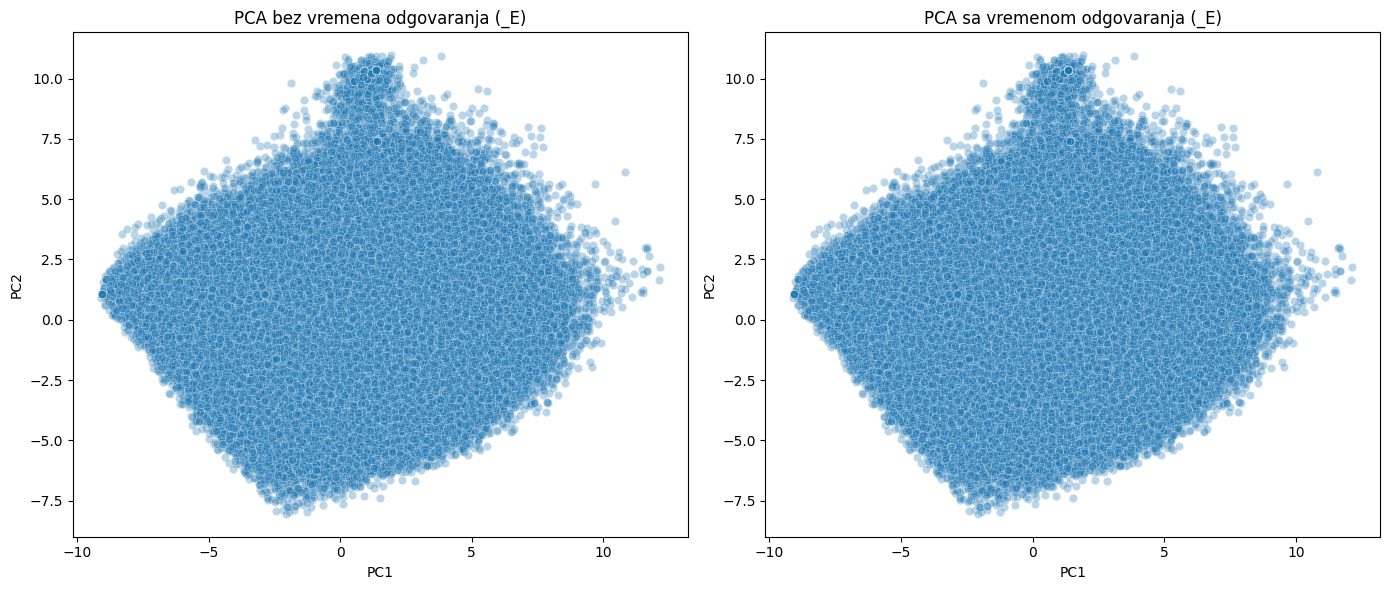

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    x="PC1", y="PC2",
    data=df_pca_noE,
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title("PCA bez vremena odgovaranja (_E)")

sns.scatterplot(
    x="PC1", y="PC2",
    data=df_pca_withE,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("PCA sa vremenom odgovaranja (_E)")

plt.tight_layout()
plt.show()


In [21]:
from sklearn.cluster import KMeans

kmeans_noE = KMeans(n_clusters=5, random_state=42)
labels_noE = kmeans_noE.fit_predict(X_noE_scaled)

df_pca_noE["cluster"] = labels_noE

kmeans_withE = KMeans(n_clusters=5, random_state=42)
labels_withE = kmeans_withE.fit_predict(X_withE_scaled)

df_pca_withE["cluster"] = labels_withE


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/ksenija/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


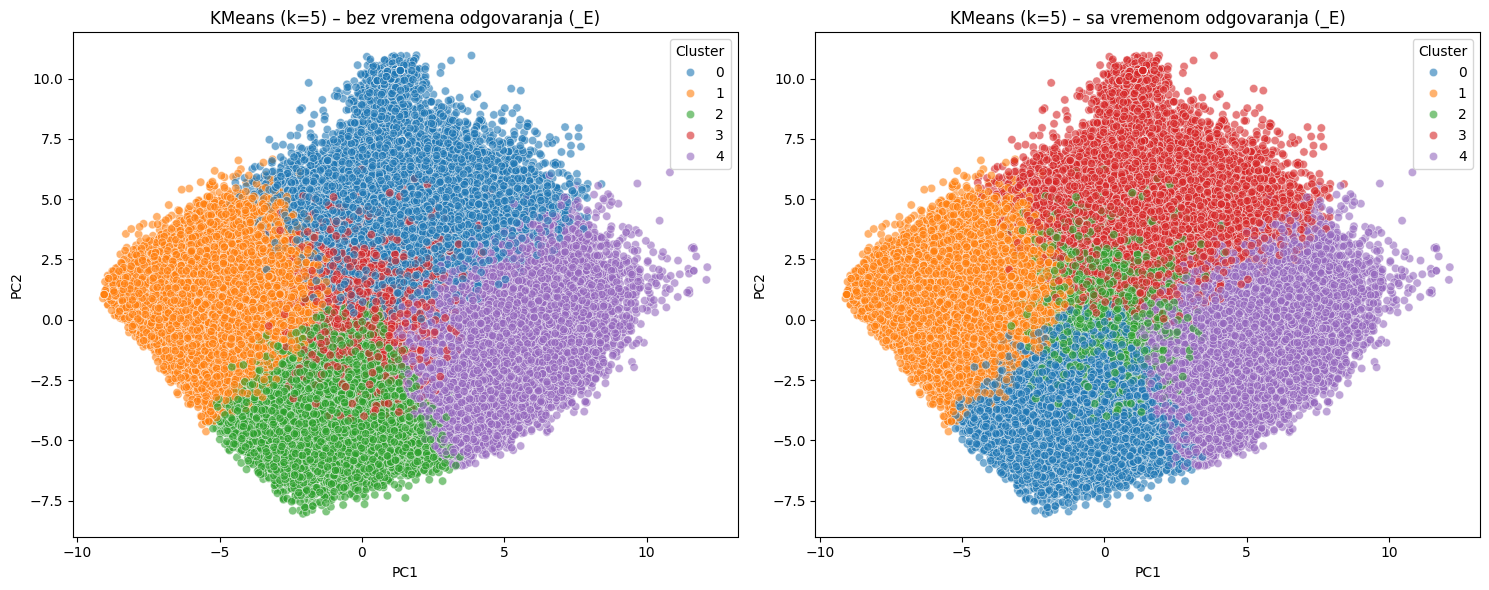

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    x="PC1", y="PC2",
    hue="cluster",
    data=df_pca_noE,
    palette="tab10",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("KMeans (k=5) – bez vremena odgovaranja (_E)")
axes[0].legend(title="Cluster")

sns.scatterplot(
    x="PC1", y="PC2",
    hue="cluster",
    data=df_pca_withE,
    palette="tab10",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("KMeans (k=5) – sa vremenom odgovaranja (_E)")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.utils import resample

X_sample_noE, labels_sample_noE = resample(
    X_noE_scaled, labels_noE,
    n_samples=15000,
    random_state=42
)

sil_noE = silhouette_score(X_sample_noE, labels_sample_noE)
db_noE = davies_bouldin_score(X_sample_noE, labels_sample_noE)
ch_noE = calinski_harabasz_score(X_sample_noE, labels_sample_noE)

print(sil_noE)
print(db_noE)
print(ch_noE)

0.05139661585508497
2.941067001711615
880.598012247979


In [24]:
X_sample_withE, labels_sample_withE = resample(
    X_withE_scaled, labels_withE,
    n_samples=15000,
    random_state=42
)

sil_withE = silhouette_score(X_sample_withE, labels_sample_withE)
db_withE = davies_bouldin_score(X_sample_withE, labels_sample_withE)
ch_withE = calinski_harabasz_score(X_sample_withE, labels_sample_withE)

#deluju lose al nisu jer big five nema u prirodi bas klastere a kmeans ih forsira
print(sil_withE)
print(db_withE)
print(ch_withE)

0.04825497124274216
3.067059563082845
238.1448154263935


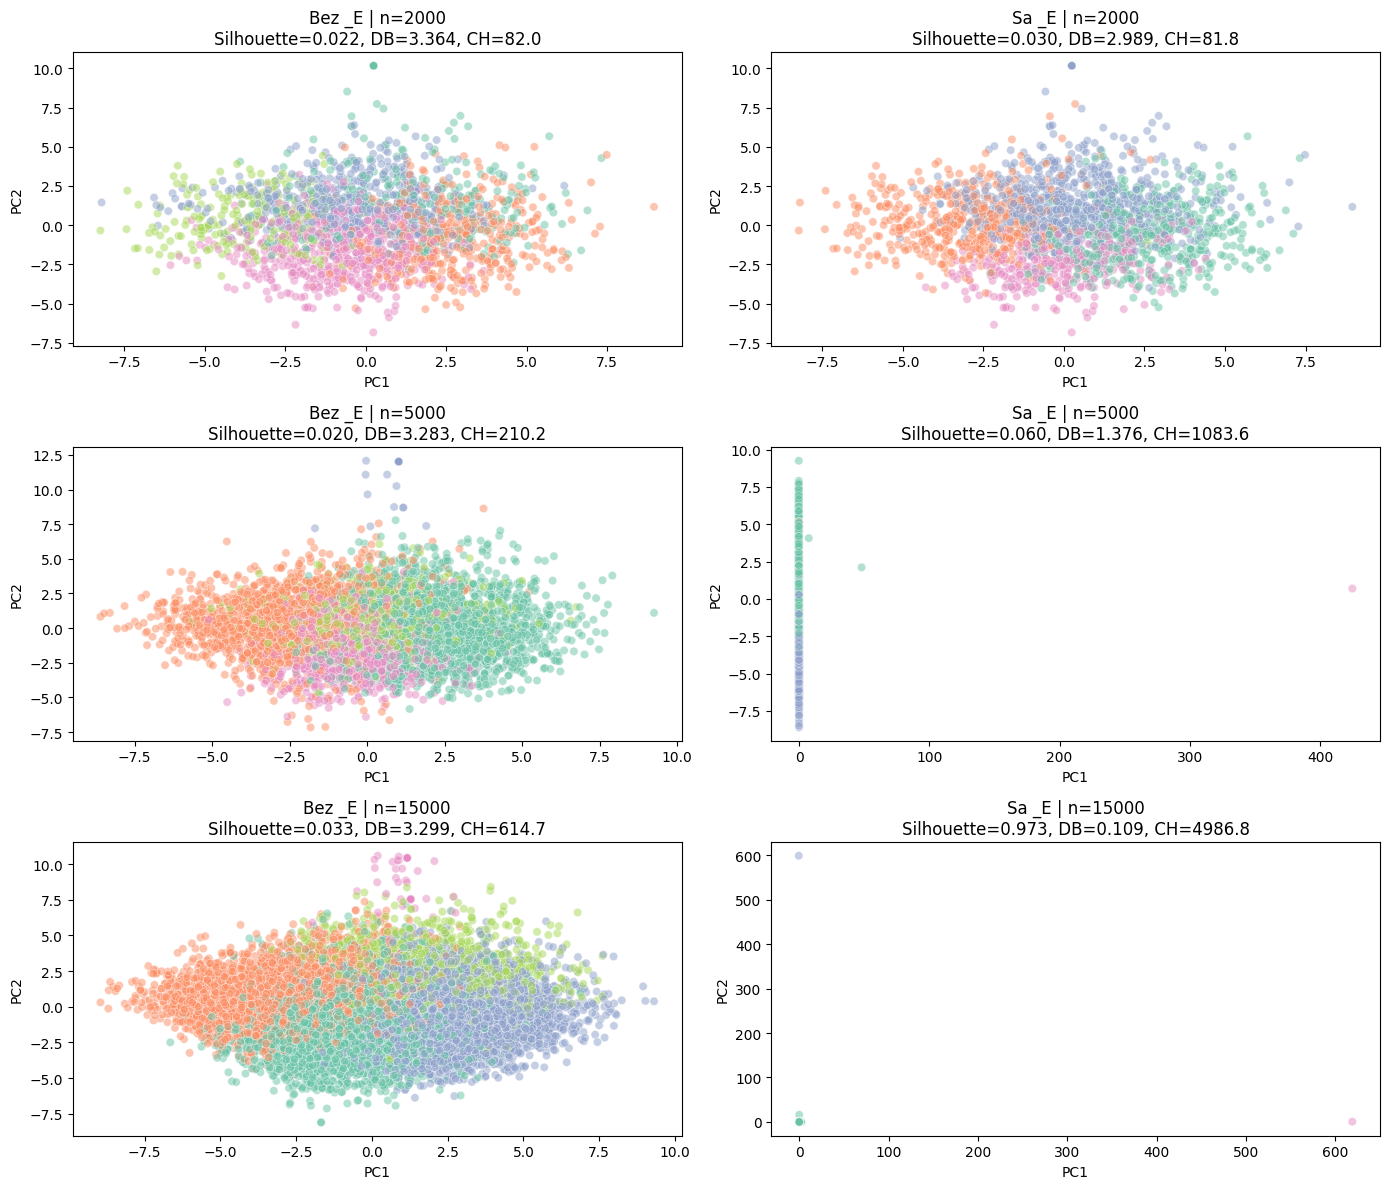

In [25]:
from sklearn.cluster import AgglomerativeClustering

#Agglomerative je testiran na reprezentativnom uzorku zbog ograničenja memorije
sample_sizes = [2000, 5000, 15000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):
    # --- Bez _E ---
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)
    agg_noE = AgglomerativeClustering(n_clusters=5, linkage="ward")
    labels_noE = agg_noE.fit_predict(X_sample_noE)
    
    # Metrike
    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)
    
    # PCA za vizualizaciju
    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_noE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )
    axes[i, 0].set_title(
        f"Bez _E | n={n}\nSilhouette={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )
    
    # --- Sa _E ---
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)
    agg_withE = AgglomerativeClustering(n_clusters=5, linkage="ward")
    labels_withE = agg_withE.fit_predict(X_sample_withE)
    
    # Metrike
    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)
    
    # PCA
    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_withE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    axes[i, 1].set_title(
        f"Sa _E | n={n}\nSilhouette={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()


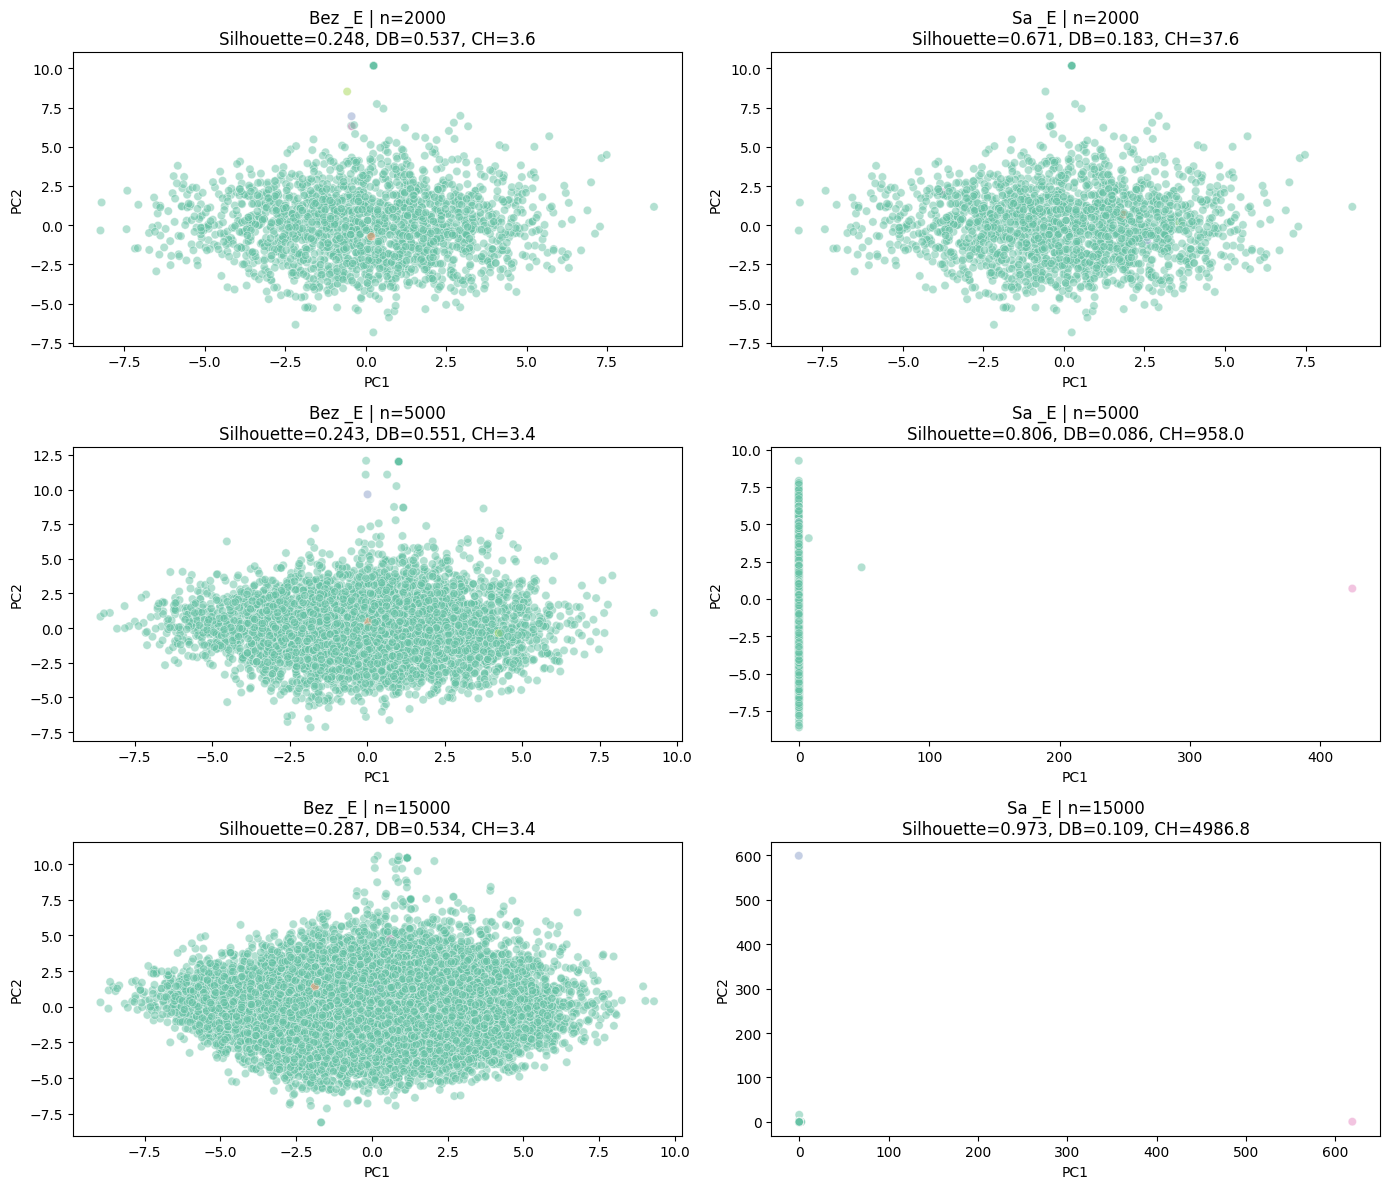

In [26]:
sample_sizes = [2000, 5000, 15000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):
    # --- Bez _E ---
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)
    agg_noE = AgglomerativeClustering(n_clusters=5, linkage="single")
    labels_noE = agg_noE.fit_predict(X_sample_noE)
    
    # Metrike
    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)
    
    # PCA za vizualizaciju
    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_noE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )
    axes[i, 0].set_title(
        f"Bez _E | n={n}\nSilhouette={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )
    
    # --- Sa _E ---
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)
    agg_withE = AgglomerativeClustering(n_clusters=5, linkage="single")
    labels_withE = agg_withE.fit_predict(X_sample_withE)
    
    # Metrike
    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)
    
    # PCA
    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_withE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    axes[i, 1].set_title(
        f"Sa _E | n={n}\nSilhouette={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()


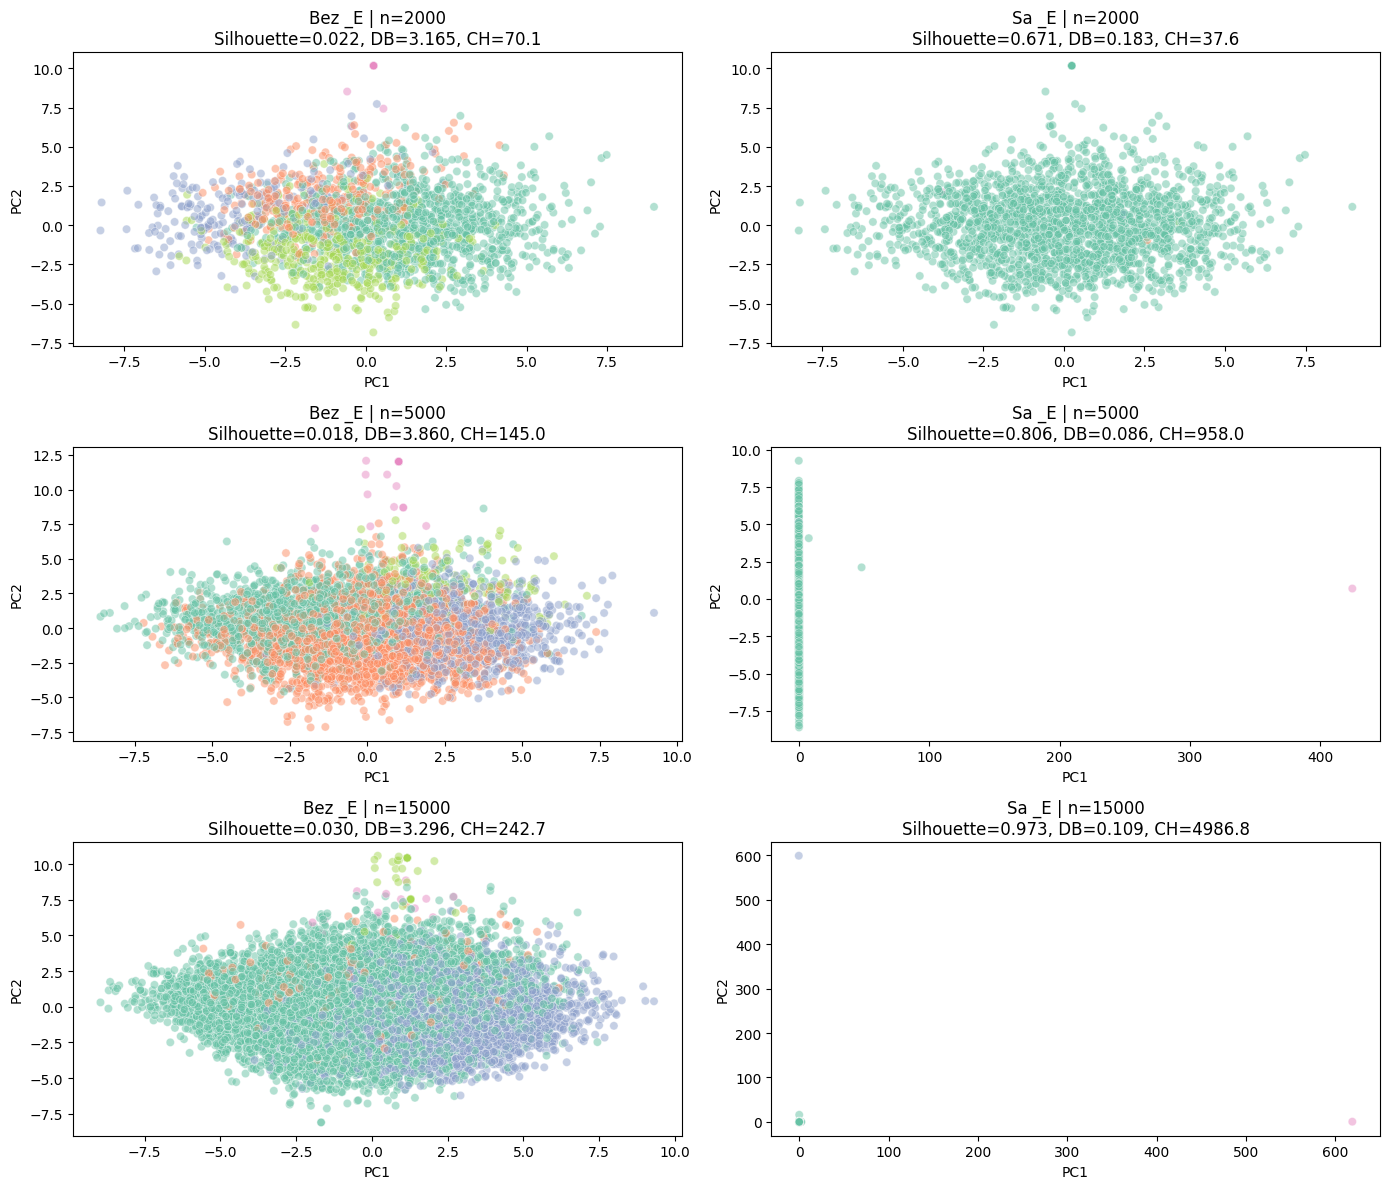

In [27]:
sample_sizes = [2000, 5000, 15000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):
    # --- Bez _E ---
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)
    agg_noE = AgglomerativeClustering(n_clusters=5, linkage="complete")
    labels_noE = agg_noE.fit_predict(X_sample_noE)
    
    # Metrike
    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)
    
    # PCA za vizualizaciju
    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_noE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )
    axes[i, 0].set_title(
        f"Bez _E | n={n}\nSilhouette={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )
    
    # --- Sa _E ---
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)
    agg_withE = AgglomerativeClustering(n_clusters=5, linkage="complete")
    labels_withE = agg_withE.fit_predict(X_sample_withE)
    
    # Metrike
    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)
    
    # PCA
    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_withE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    axes[i, 1].set_title(
        f"Sa _E | n={n}\nSilhouette={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()


[-1  0  1]
{-1: 371, 0: 125, 1: 4}
[-1  0  1]
{-1: 1116, 0: 879, 1: 5}
[-1  0  1]
{-1: 2360, 0: 2625, 1: 15}
[-1  0  1  2  3]
{-1: 3898, 0: 6065, 1: 6, 2: 26, 3: 5}


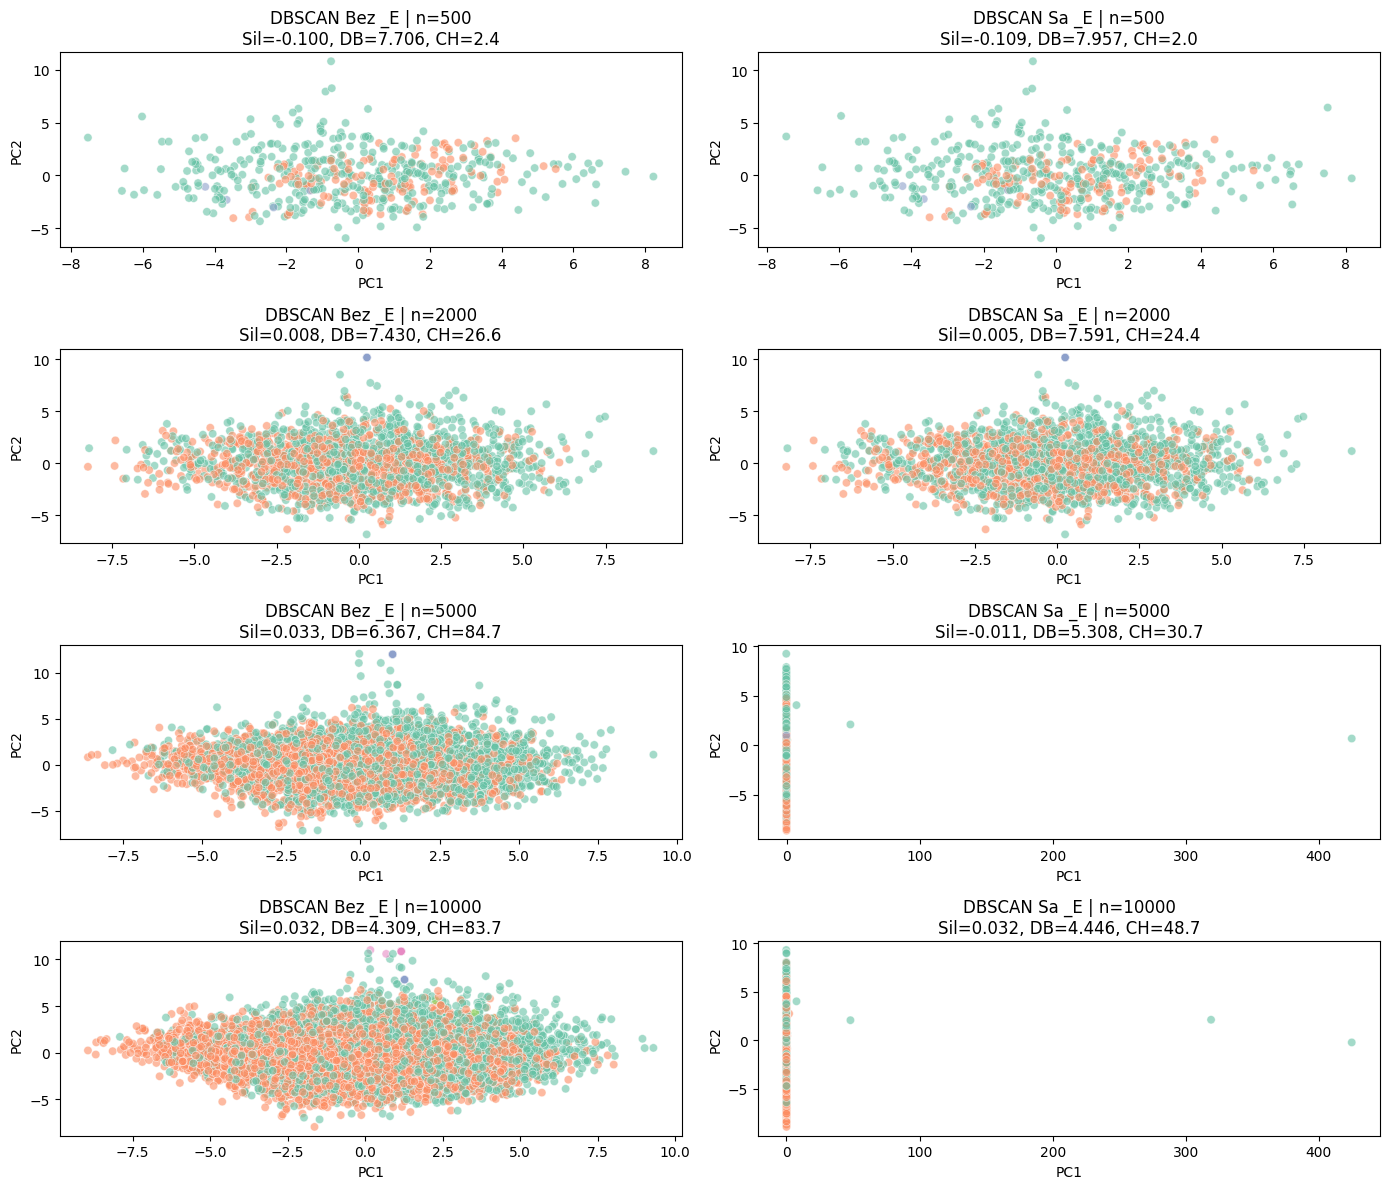

In [28]:
from sklearn.cluster import DBSCAN

sample_sizes = [500,2000, 5000, 10000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):

    # ---------------- BEZ _E ----------------
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)
    
    db_noE = DBSCAN(eps=5.5, min_samples=4)
    labels_noE = db_noE.fit_predict(X_sample_noE)
    
    # Metrike (samo ako ima više od 1 klastera bez noise-only)
    unique_noE = set(labels_noE)
    if len(unique_noE - {-1}) > 1:
        sil_noE = silhouette_score(X_sample_noE, labels_noE)
        db_noE_score = davies_bouldin_score(X_sample_noE, labels_noE)
        ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)
    else:
        sil_noE, db_noE_score, ch_noE = float("nan"), float("nan"), float("nan")
    
    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    df_pca_noE["cluster"] = labels_noE
    
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="Set2",
        alpha=0.6,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )
    
    axes[i, 0].set_title(
        f"DBSCAN Bez _E | n={n}\nSil={sil_noE:.3f}, DB={db_noE_score:.3f}, CH={ch_noE:.1f}"
    )


    # ---------------- SA _E ----------------
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)
    
    db_withE = DBSCAN(eps=5.5, min_samples=4)
    labels_withE = db_withE.fit_predict(X_sample_withE)
    
    unique_withE = set(labels_withE)
    if len(unique_withE - {-1}) > 1:
        sil_withE = silhouette_score(X_sample_withE, labels_withE)
        db_withE_score = davies_bouldin_score(X_sample_withE, labels_withE)
        ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)
    else:
        sil_withE, db_withE_score, ch_withE = float("nan"), float("nan"), float("nan")
    
    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    df_pca_withE["cluster"] = labels_withE
    
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="Set2",
        alpha=0.6,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    
    axes[i, 1].set_title(
        f"DBSCAN Sa _E | n={n}\nSil={sil_withE:.3f}, DB={db_withE_score:.3f}, CH={ch_withE:.1f}"
    )
    print(np.unique(labels_noE))
    unique, counts = np.unique(labels_noE, return_counts=True)
    print(dict(zip(unique, counts)))

plt.tight_layout()
plt.show()



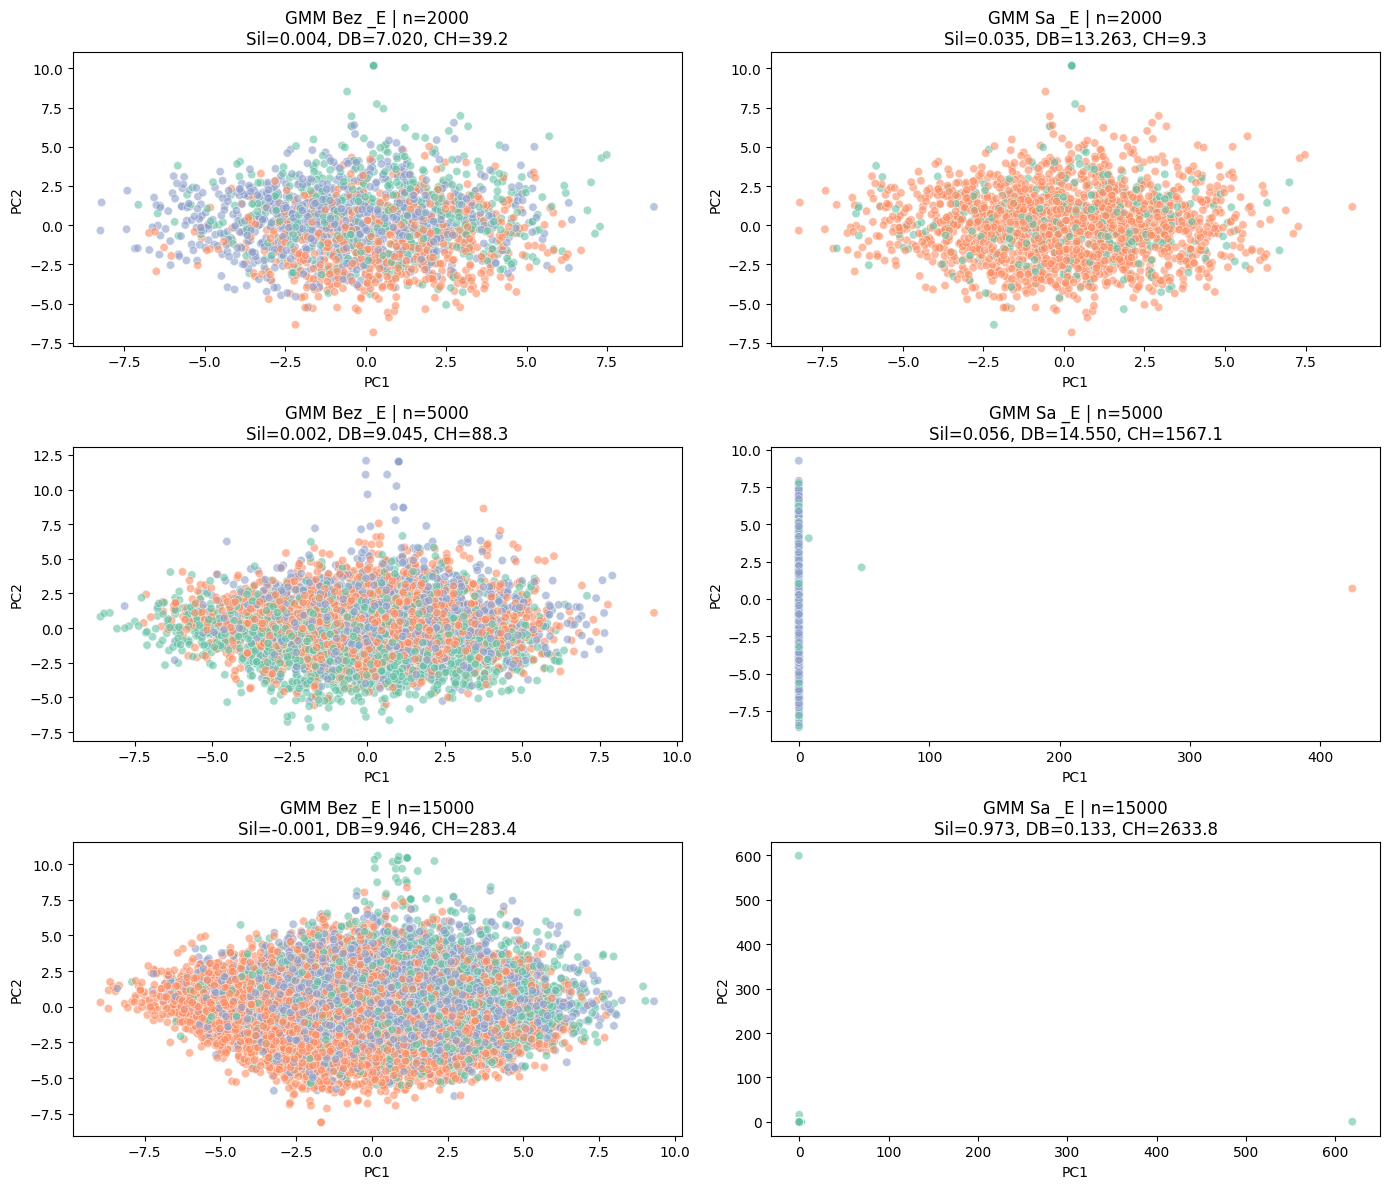

In [29]:
from sklearn.mixture import GaussianMixture

sample_sizes = [2000, 5000, 15000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):

    # ---------------- BEZ _E ----------------
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)

    gmm_noE = GaussianMixture(n_components=3, random_state=42)
    labels_noE = gmm_noE.fit_predict(X_sample_noE)

    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)

    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    df_pca_noE["cluster"] = labels_noE

    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="Set2",
        alpha=0.6,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )

    axes[i, 0].set_title(
        f"GMM Bez _E | n={n}\nSil={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )


    # ---------------- SA _E ----------------
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)

    gmm_withE = GaussianMixture(n_components=3, random_state=42)
    labels_withE = gmm_withE.fit_predict(X_sample_withE)

    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)

    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    df_pca_withE["cluster"] = labels_withE

    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="Set2",
        alpha=0.6,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )

    axes[i, 1].set_title(
        f"GMM Sa _E | n={n}\nSil={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()



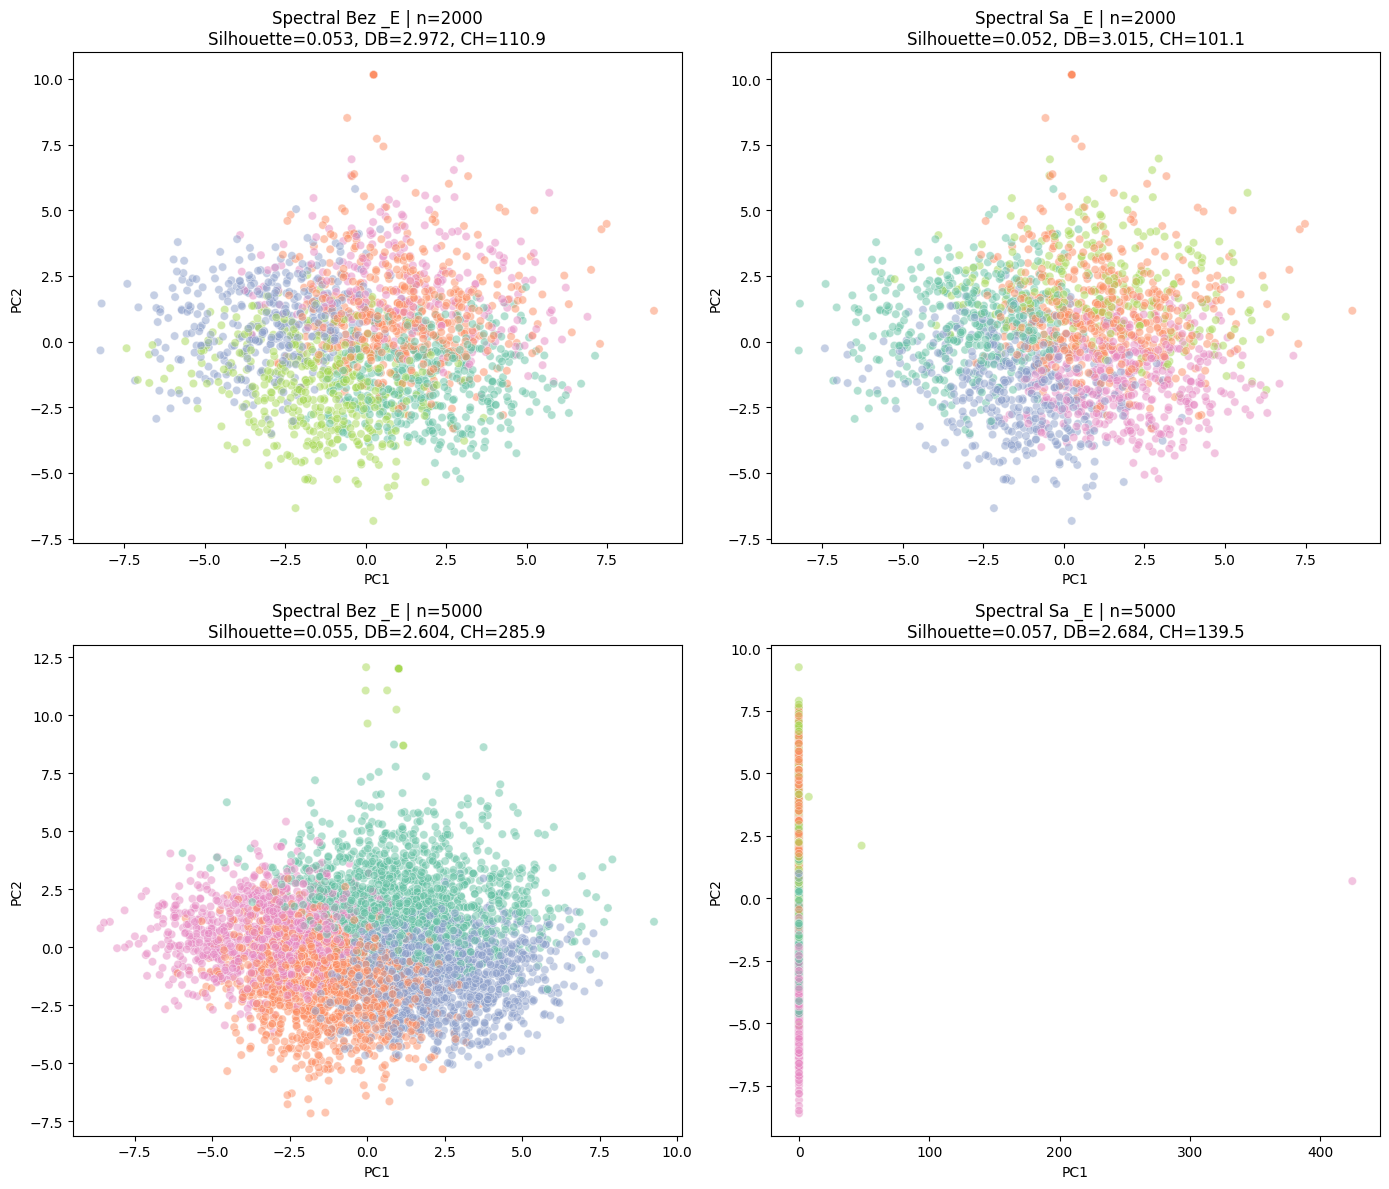

In [34]:
from sklearn.cluster import SpectralClustering


sample_sizes = [2000,5000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 12))

for i, n in enumerate(sample_sizes):
    # --- Bez _E ---
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)
    spectral_noE = SpectralClustering(n_clusters=5,affinity="nearest_neighbors",n_neighbors=20, random_state=42, n_init=10)
    labels_noE = spectral_noE.fit_predict(X_sample_noE)
    
    # Metrike
    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)
    
    # PCA za vizualizaciju
    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_noE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )
    axes[i, 0].set_title(
        f"Spectral Bez _E | n={n}\nSilhouette={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )
    
    # --- Sa _E ---
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)
    spectral_withE = SpectralClustering(n_clusters=5,affinity="nearest_neighbors",n_neighbors=20, random_state=42, n_init=10)
    labels_withE = spectral_withE.fit_predict(X_sample_withE)
    
    # Metrike
    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)
    
    # PCA
    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    
    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_withE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    axes[i, 1].set_title(
        f"Spectral Sa _E | n={n}\nSilhouette={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


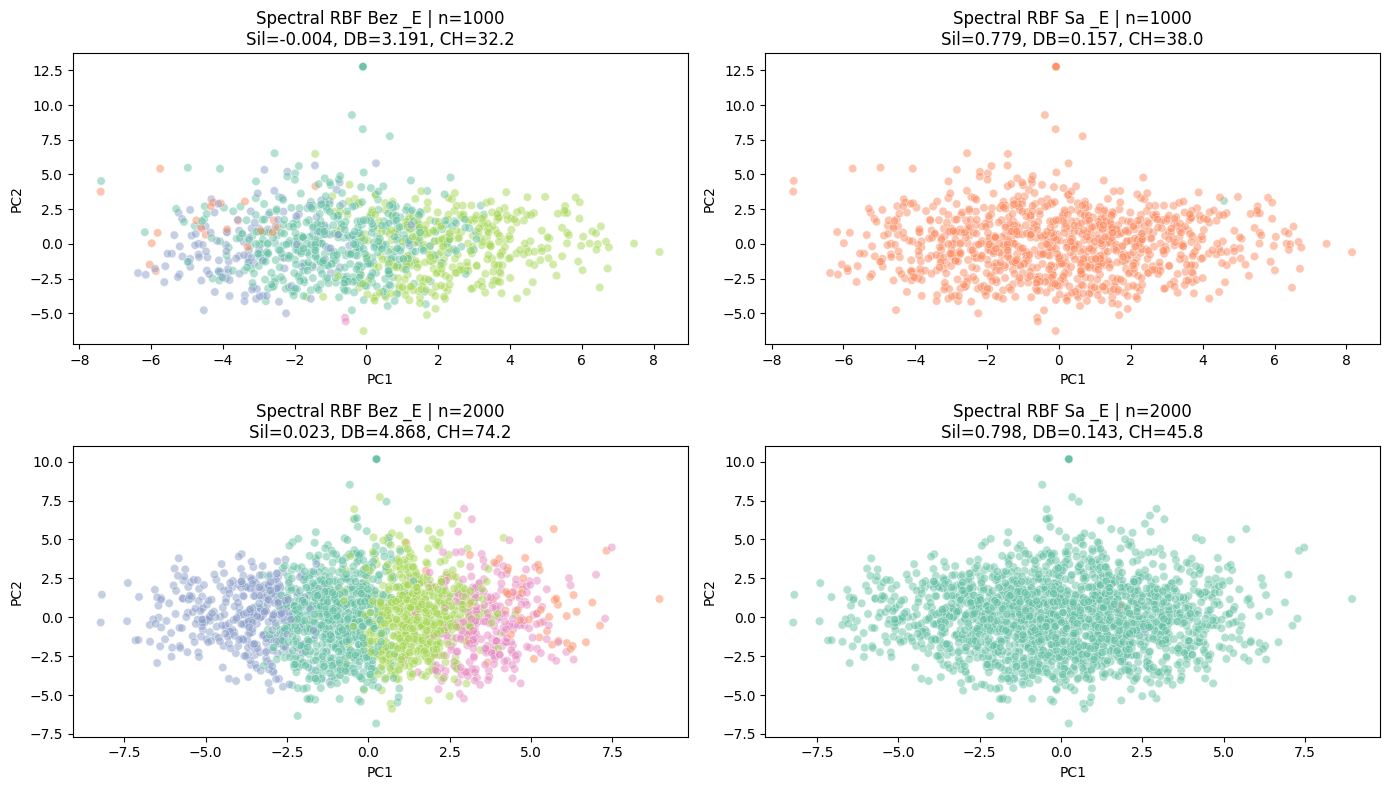

In [39]:
sample_sizes = [1000, 2000]

fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 8), squeeze=False)

for i, n in enumerate(sample_sizes):

    # ---------------- BEZ _E ----------------
    X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)

    spectral_noE = SpectralClustering(
        n_clusters=5,
        affinity="rbf",
        gamma=0.25,          
        random_state=42
    )

    labels_noE = spectral_noE.fit_predict(X_sample_noE)

    sil_noE = silhouette_score(X_sample_noE, labels_noE)
    db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
    ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)

    df_pca_noE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_noE),
        columns=["PC1", "PC2"]
    )
    df_pca_noE["cluster"] = labels_noE

    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_noE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_noE,
        ax=axes[i, 0],
        legend=False
    )

    axes[i, 0].set_title(
        f"Spectral RBF Bez _E | n={n}\nSil={sil_noE:.3f}, DB={db_noE:.3f}, CH={ch_noE:.1f}"
    )


    # ---------------- SA _E ----------------
    X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)

    spectral_withE = SpectralClustering(
        n_clusters=5,
        affinity="rbf",
        gamma=0.25,
        random_state=42
    )

    labels_withE = spectral_withE.fit_predict(X_sample_withE)

    sil_withE = silhouette_score(X_sample_withE, labels_withE)
    db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
    ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)

    df_pca_withE = pd.DataFrame(
        PCA(n_components=2).fit_transform(X_sample_withE),
        columns=["PC1", "PC2"]
    )
    df_pca_withE["cluster"] = labels_withE

    sns.scatterplot(
        x="PC1", y="PC2",
        hue=labels_withE,
        palette="Set2",
        alpha=0.5,
        data=df_pca_withE,
        ax=axes[i, 1],
        legend=False
    )
    axes[i, 1].set_title(
        f"Spectral RBF Sa _E | n={n}\nSil={sil_withE:.3f}, DB={db_withE:.3f}, CH={ch_withE:.1f}"
    )

plt.tight_layout()
plt.show()




================= GAMMA = 0.1 =================

[Bez _E | n=1000]
Cluster sizes: [220 339 357  78   6]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=1000]
Cluster sizes: [944   1   1   0  54]

[Bez _E | n=2000]
Cluster sizes: [685   7 694   2 612]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=2000]
Cluster sizes: [   0    1    1 1998]


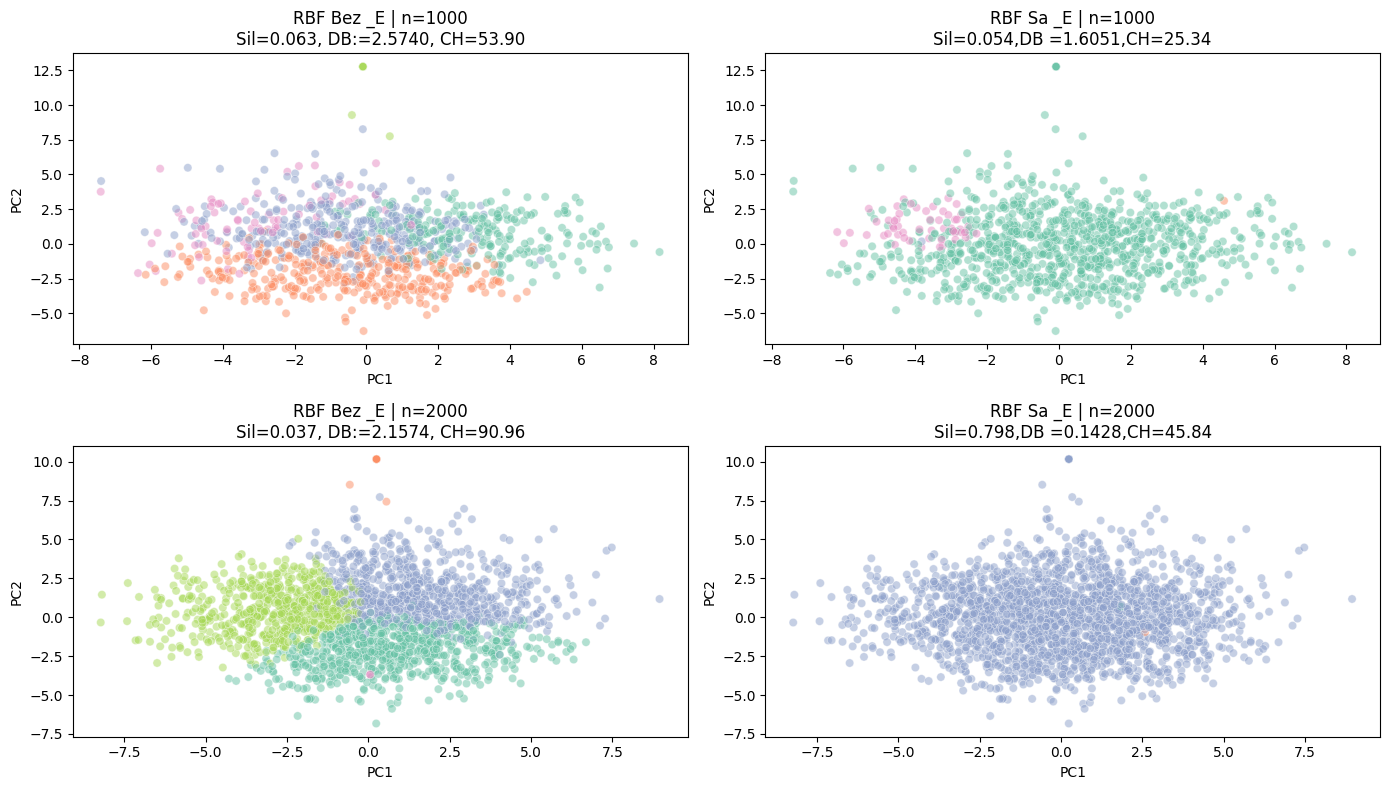


================= GAMMA = 0.25 =================

[Bez _E | n=1000]
Cluster sizes: [500  21 127   2 350]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=1000]
Cluster sizes: [  0   1 999]

[Bez _E | n=2000]
Cluster sizes: [721  54 357 264 604]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=2000]
Cluster sizes: [1998    1    1]


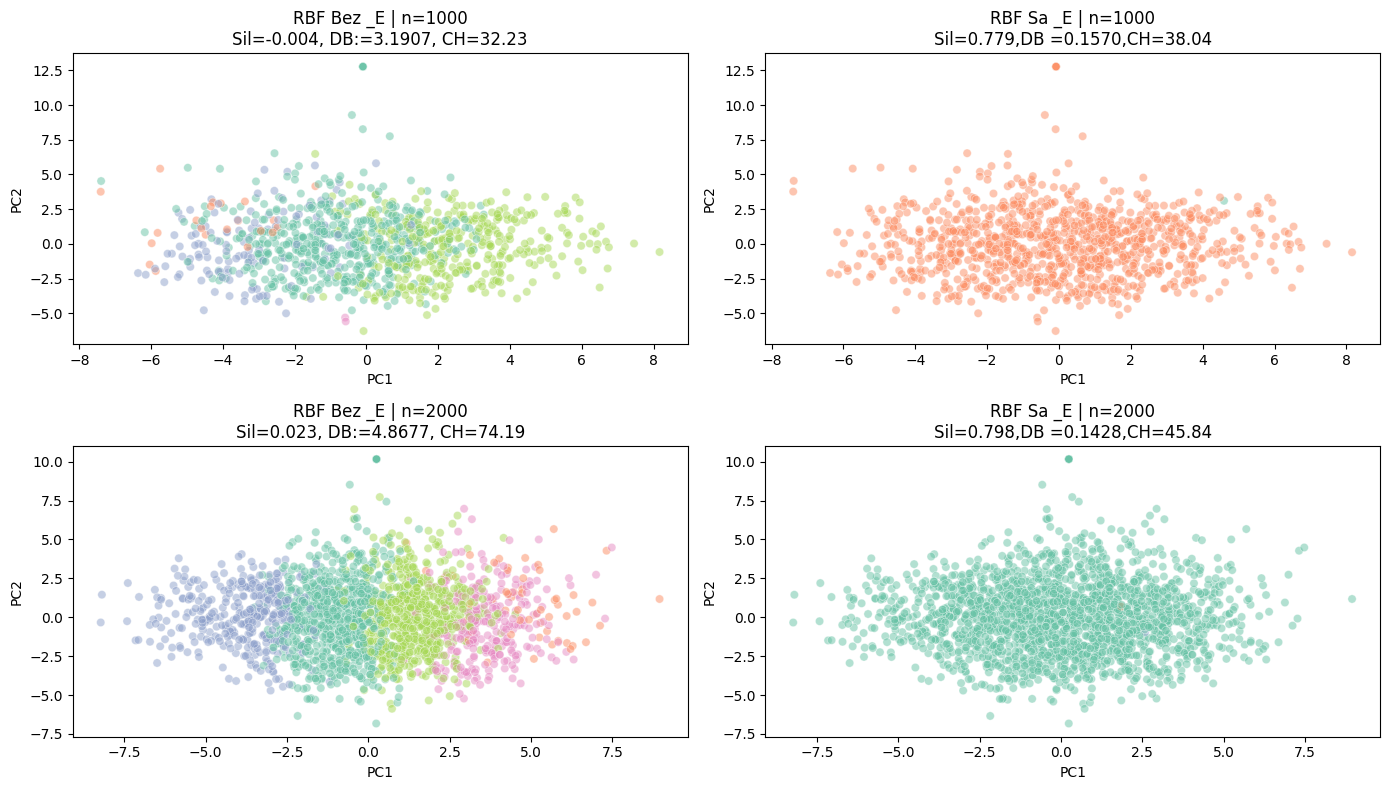


================= GAMMA = 0.5 =================

[Bez _E | n=1000]
Cluster sizes: [815   2   1   3 179]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=1000]
Cluster sizes: [  0   1 999]

[Bez _E | n=2000]
Cluster sizes: [1966    2    1   14   17]


/home/ksenija/.local/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/ksenija/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)



[Sa _E | n=2000]
Cluster sizes: [   0    1 1999]


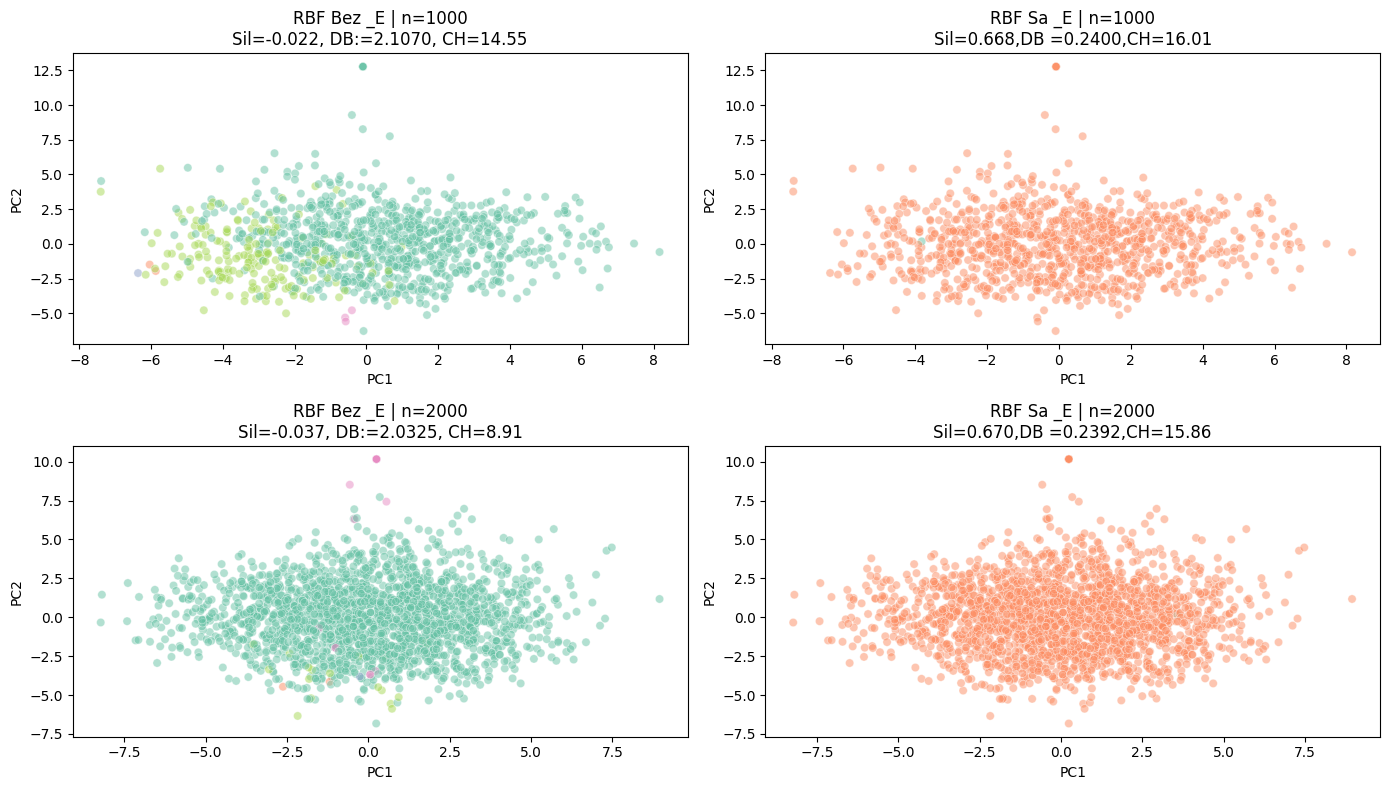

In [41]:
import numpy as np
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_sizes = [1000, 2000]
gamma_values = [0.1, 0.25, 0.5]

for gamma in gamma_values:

    print(f"\n================= GAMMA = {gamma} =================")

    fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(14, 8), squeeze=False)

    for i, n in enumerate(sample_sizes):

        # ---------------- BEZ _E ----------------
        X_sample_noE = resample(X_noE_scaled, n_samples=n, random_state=42)

        spectral_noE = SpectralClustering(
            n_clusters=5,
            affinity="rbf",
            gamma=gamma,
            random_state=42
        )

        labels_noE = spectral_noE.fit_predict(X_sample_noE)

        sil_noE = silhouette_score(X_sample_noE, labels_noE)
        db_noE = davies_bouldin_score(X_sample_noE, labels_noE)
        ch_noE = calinski_harabasz_score(X_sample_noE, labels_noE)

        print(f"\n[Bez _E | n={n}]")
        print("Cluster sizes:", np.bincount(labels_noE))
        

        df_pca_noE = pd.DataFrame(
            PCA(n_components=2).fit_transform(X_sample_noE),
            columns=["PC1", "PC2"]
        )
        df_pca_noE["cluster"] = labels_noE

        sns.scatterplot(
            x="PC1", y="PC2",
            hue="cluster",
            palette="Set2",
            alpha=0.5,
            data=df_pca_noE,
            ax=axes[i, 0],
            legend=False
        )

        axes[i, 0].set_title(
            f"RBF Bez _E | n={n}\nSil={sil_noE:.3f}, DB:={db_noE:.4f}, CH={ch_noE:.2f}"
        )

        # ---------------- SA _E ----------------
        X_sample_withE = resample(X_withE_scaled, n_samples=n, random_state=42)

        spectral_withE = SpectralClustering(
            n_clusters=5,
            affinity="rbf",
            gamma=gamma,
            random_state=42
        )

        labels_withE = spectral_withE.fit_predict(X_sample_withE)

        sil_withE = silhouette_score(X_sample_withE, labels_withE)
        db_withE = davies_bouldin_score(X_sample_withE, labels_withE)
        ch_withE = calinski_harabasz_score(X_sample_withE, labels_withE)

        print(f"\n[Sa _E | n={n}]")
        print("Cluster sizes:", np.bincount(labels_withE))
        

        df_pca_withE = pd.DataFrame(
            PCA(n_components=2).fit_transform(X_sample_withE),
            columns=["PC1", "PC2"]
        )
        df_pca_withE["cluster"] = labels_withE

        sns.scatterplot(
            x="PC1", y="PC2",
            hue="cluster",
            palette="Set2",
            alpha=0.5,
            data=df_pca_withE,
            ax=axes[i, 1],
            legend=False
        )

        axes[i, 1].set_title(
            f"RBF Sa _E | n={n}\nSil={sil_withE:.3f},DB ={db_withE:.4f},CH={ch_withE:.2f}"
        )

    plt.tight_layout()
    plt.show()
